In [1]:
#| hide
# BASED ON
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
      
# TODO
# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


In [2]:
versioninfo() ##. Julia version

Julia Version 1.10.0
Commit 3120989f39b (2023-12-25 18:01 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
  Threads: 1 on 12 virtual cores
Environment:
  JULIA_NUM_THREADS = 


In [3]:
# Activate local environment, see `Project.toml`
import Pkg; Pkg.activate(".."); Pkg.instantiate();

using RxInfer, BenchmarkTools, Random, LinearAlgebra, Plots, LaTeXStrings, Distributions, StableRNGs

  Activating project at `/workspaces/3.0.0_RxInfer.jl/examples`


In [4]:
Pkg.status()

Status `/workspaces/3.0.0_RxInfer.jl/examples/Project.toml`
⌃ [b4ee3484] BayesBase v1.2.1
  [6e4b80f9] BenchmarkTools v1.5.0
  [336ed68f] CSV v0.10.14
⌃ [159f3aea] Cairo v1.0.5
  [a81c6b42] Compose v0.9.5
  [a93c6f00] DataFrames v1.6.1
⌃ [31c24e10] Distributions v0.25.108
⌃ [62312e5e] ExponentialFamily v1.4.1
⌃ [587475ba] Flux v0.14.11
  [38e38edf] GLM v1.9.0
⌅ [b3f8163a] GraphPPL v4.0.2
⌃ [a2cc645c] GraphPlot v0.5.2
  [f526b714] GraphViz v0.2.0
⌃ [86223c79] Graphs v1.9.0
⌃ [34004b35] HypergeometricFunctions v0.3.23
⌃ [7073ff75] IJulia v1.24.2
  [4138dd39] JLD v0.13.5
  [b964fa9f] LaTeXStrings v1.3.1
  [b81a8e73] LatexSVG v0.3.1
⌃ [23fbe1c1] Latexify v0.16.3
  [429524aa] Optim v1.9.4
⌃ [3bd65402] Optimisers v0.2.20
⌃ [3b7a836e] PGFPlots v3.4.4
  [8314cec4] PGFPlotsX v1.6.1
  [d96e819e] Parameters v0.12.3
⌃ [91a5bcdd] Plots v1.40.1
⌃ [92933f4c] ProgressMeter v1.10.0
⌅ [a194aa59] ReactiveMP v4.0.0
  [37e2e3b7] ReverseDiff v1.15.3
⌃ [df971d30] Rocket v1.8.0
⌃ [86711068] RxInfer v3.0.0
  [

# Kalman filtering and smoothing

In the following set of examples the goal is to estimate hidden <u>states</u> of a Dynamical process where all hidden states are Gaussians.

We start our journey with a simple 

- (1) multivariate Linear Gaussian State Space Model (LGSSM), which can be solved analytically. We then solve an 
- (2) identification problem which does not have an analytical solution. Utimately, we show how **RxInfer.jl** can 
- (3) deal with missing observations.

## 1 Gaussian Linear Dynamical System

LGSSM can be described with the following equations:

$$\begin{aligned}
 p(\mathbf{s}_t|\mathbf{s}_{t - 1}) & = \mathcal{N}(\mathbf{s}_t|\mathbf{B} \mathbf{s}_{t - 1}, \mathbf{Q}),\\
 p(\mathbf{y}_t|\mathbf{s}_t) & = \mathcal{N}(\mathbf{y}_t|\mathbf{A} \mathbf{s}_t, \mathbf{R}),
\end{aligned}$$

where $\mathbf{s}_t$ are hidden states, $\mathbf{y}_t$ are noisy observations, $\mathbf{B}$, $\mathbf{A}$ are state transition and observation matrices, $\mathbf{Q}$ and $\mathbf{R}$ are state transition noise and observation noise covariance matrices. For a more rigorous introduction to Linear Gaussian Dynamical systems we refer to [Simo Sarkka, Bayesian Filtering and Smoothing](https://users.aalto.fi/~ssarkka/pub/cup_book_online_20131111.pdf) book.

In [5]:
_seed = 1234
_rng = MersenneTwister(1234)

## We will model 2-dimensional observations with rotation matrix `B`
## To avoid clutter we also assume that matrices `B`, `A`, `Q`, and `R`
## are known and fixed for all time-steps
_s̃₀ = [ 10.0, -10.0 ]
_θ̃ = π / 35
# _Ã = [ cos(_θ̃) -sin(_θ̃); sin(_θ̃) cos(_θ̃) ]
_B̃ = [ cos(_θ̃) -sin(_θ̃); sin(_θ̃) cos(_θ̃) ]
# _B̃ = diageye(2)
_Ã = diageye(2)
_Q̃ = diageye(2)
# _P̃ = 25.0 .* diageye(2)
_R̃ = 25.0 .* diageye(2)
_T = 300; ## number of observations

Next step, is to generate some synthetic data.

### Provision function ($f_p$)
The *provision* function, provides another covariate vector. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function:

$$\tilde{\mathbf{p}}_{t} = f_p(\tilde{\mathbf{s}}_{t-1}) = f_B(\tilde{\mathbf{s}}_{t-1}) = \tilde{\mathbf{B}} \tilde{\mathbf{s}}_{t-1}$$

$$\tilde{\mathbf{s}}_{t} = \mathcal{N}(\tilde{\mathbf{p}}_{t}, \mathbf{\tilde{Q}})$$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [6]:
## provision function, provides another covariate vector
function fₚ(; B̃, s̃ₜ₋₁)
    return B̃*s̃ₜ₋₁
end
fₚ(B̃=_B̃, s̃ₜ₋₁=_s̃₀)

2-element Vector{Float64}:
 10.856136028986725
 -9.063349850918055

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector.
$$\tilde{\mathbf{r}}_{t} = f_r(\tilde{\mathbf{s}}_{t}) = f_A(\tilde{\mathbf{s}}_{t}) = \tilde{\mathbf{A}} \tilde{\mathbf{s}}_{t} $$

$$\mathbf{y}_{t} = \mathcal{N}(f_r(\tilde{\mathbf{s}}_{t}), \mathbf{\tilde{R}}) = \mathcal{N}(\tilde{\mathbf{r}}_{t}, \mathbf{\tilde{R}})$$


The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [7]:
## response function, provides the response to covariate vector
function fᵣ(; Ã, s̃ₜ)
    return Ã*s̃ₜ
end
fᵣ(; Ã=_Ã, s̃ₜ=_s̃₀)

2-element Vector{Float64}:
  10.0
 -10.0

In [8]:
# function sim_point_data(rng, T, Ã, B̃, Q̃, P̃) ## simulated point data
# function sim_point_data(rng, T, B̃, Ã, Q̃, P̃) ## simulated point data
## sim|lab OR fld _ batch OR point|obser
## batch is along 'depth/examples' dimension
## batch is along 'time' dimension
function sim_batch_data(rng, T, B̃, Ã, Q̃, R̃) ## simulated batch data
    s̃ₜ₋₁ = _s̃₀
    p̃ = Vector{Vector{Float64}}(undef, T)
    s̃ = Vector{Vector{Float64}}(undef, T)
    r̃ = Vector{Vector{Float64}}(undef, T)
    y = Vector{Vector{Float64}}(undef, T)
    for t in 1:T
        # s̃[t] = rand(rng, MvNormal(Ã*s̃ₜ₋₁, Q̃))
        # //////////////////////////
        # p̃[t] = B̃*s̃ₜ₋₁
        p̃[t] = fₚ(B̃=B̃, s̃ₜ₋₁=s̃ₜ₋₁)
        s̃[t] = rand(rng, MvNormal(p̃[t], Q̃))
        # s̃[t] = rand(rng, MvNormal(B̃*s̃ₜ₋₁, Q̃))        
        # \\\\\
        ## s̃[t] = rand(rng, MvNormal(f(B̃= B̃, s̃ₜ₋₁= s̃ₜ₋₁), Q̃))
        # y[t] = rand(rng, MvNormal(B̃*s̃[t], P̃))
        # y[t] = rand(rng, MvNormal(Ã*s̃[t], P̃))
        # /////////////////////////////
        # r̃[t] = Ã*s̃[t]
        r̃[t] = fᵣ(Ã=Ã, s̃ₜ=s̃[t])
        y[t] = rand(rng, MvNormal(r̃[t], R̃))
        # y[t] = rand(rng, MvNormal(Ã*s̃[t], R̃))        
        # \\\\\\\\\
        ## y[t] = rand(rng, MvNormal(g(Ã= Ã, s̃ₜ= s̃[t]), R̃))
        s̃ₜ₋₁ = s̃[t]
    end
    return s̃, y
end

sim_batch_data (generic function with 1 method)

In [9]:
# _s̃, _y = sim_point_data(_rng, _T, _Ã, _B̃, _Q̃, _P̃);
# _s̃, _y = sim_point_data(_rng, _T, _B̃, _Ã, _Q̃, _P̃);
_s̃, _y = sim_batch_data(_rng, _T, _B̃, _Ã, _Q̃, _R̃);

In [10]:
_s̃

300-element Vector{Vector{Float64}}:
 [11.72348323093797, -9.965093666774871]
 [13.433953356799666, -6.662214695025911]
 [14.47940302752061, -5.948167903271925]
 [15.082367302413372, -2.773515689579621]
 [15.0190904154249, -1.0406633141659591]
 [16.61608054877271, -1.0869083912496964]
 [13.435259160640983, 0.332906617038909]
 [13.041178664848662, 0.9331868884552565]
 [13.20745099487252, 2.061986400670867]
 [13.866194467362085, 2.7240623329970597]
 ⋮
 [-8.900670351775474, -18.153037318140186]
 [-4.846198760964206, -18.008749910564465]
 [-2.4425949476217257, -17.86309514027969]
 [-0.1930330987239821, -16.86812800693013]
 [0.5984888183056473, -17.115109486088613]
 [1.999265873884699, -18.268734581119805]
 [3.247316037542661, -17.262857347138443]
 [4.137580852607579, -17.588597818510166]
 [6.107162996669496, -18.15648788117835]

In [11]:
_y

300-element Vector{Vector{Float64}}:
 [9.2510894634168, -14.47966513610108]
 [16.098019767647358, -8.020891675199014]
 [11.676896336616727, -6.04462681172117]
 [10.94355014332877, -2.2230350579687435]
 [15.379672181181194, -8.557810600921213]
 [22.143569744302255, -6.620557958877578]
 [14.190137248801722, 4.1792979197118205]
 [6.642817613756749, 5.919772666742777]
 [13.917322286796729, 4.668349683011124]
 [10.042201942979187, -4.98306958673917]
 ⋮
 [-9.272003783043301, -19.775893063100256]
 [-7.602820664459581, -23.251421895071957]
 [3.4344854947555037, -8.094842782373432]
 [1.1218576004967742, -19.10984945367171]
 [0.15328211552346116, -15.77054288956493]
 [6.376893388067707, -21.437054846029106]
 [12.340801468548573, -22.194772303997237]
 [-3.1281207214127154, -17.700570938696234]
 [5.013701061005852, -17.035797013986652]

Let's plot our synthetic dataset. Lines represent our hidden states we want to estimate using noisy observations, which are represented as dots.

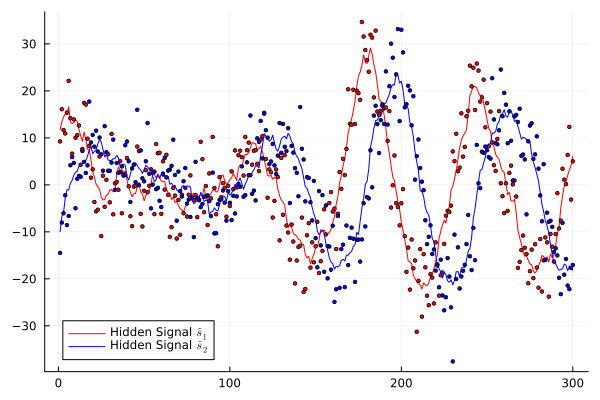

In [12]:
_p = plot()
_p = plot!(_p, getindex.(_s̃, 1), label="Hidden Signal " * L"\tilde{s}_1", color=:red)
_p = scatter!(_p, getindex.(_y, 1), label=false, markersize=2, color=:red)

_p = plot!(_p, getindex.(_s̃, 2), label="Hidden Signal " * L"\tilde{s}_2", color=:blue)
_p = scatter!(_p, getindex.(_y, 2), label=false, markersize=2, color=:blue)
plot(_p)

To create a model we use `GraphPPL` package and `@model` macro:

In [13]:
# @model function rotate_ssm(y, s₀, A, B, Q, P)
# @model function rotate_ssm(y, s₀, B, A, Q, P)
@model function rotate_ssm(y, s₀, B, A, Q, R)
    s_prior ~ MvNormalMeanCovariance(mean(s₀), cov(s₀))
    sₜ₋₁ = s_prior
    for t in 1:length(y)
        # s[t] ~ MvNormalMeanCovariance(A*sₜ₋₁, Q) ## `s` is a sequence of hidden states
        s[t] ~ MvNormalMeanCovariance(B*sₜ₋₁, Q) ## `s` is a sequence of hidden states
        ##- s[t] ~ MvNormalMeanCovariance(f(B= B, sₜ₋₁= sₜ₋₁), Q) ## `s` is a sequence of hidden states
        # y[t] ~ MvNormalMeanCovariance(B*s[t], P) ## `y` is a sequence of "clamped" observations
        # y[t] ~ MvNormalMeanCovariance(A*s[t], P) ## `y` is a sequence of "clamped" observations
        y[t] ~ MvNormalMeanCovariance(A*s[t], R) ## `y` is a sequence of "clamped" observations
        sₜ₋₁ = s[t]
    end
end

To run inference we also specify a prior for our first hidden state:

In [14]:
_s̃₀ = MvNormalMeanCovariance(zeros(2), 100.0*diageye(2));

In [15]:
## For large number of observations you need to use limit_stack_depth = 100 option during model creation, e.g. 
## infer(..., options = (limit_stack_depth = 500, ))`
_result = infer(
    # model=       rotate_ssm(s₀=_s̃₀, A=_Ã, B=_B̃, Q=_Q̃, P=_P̃),
    # model=       rotate_ssm(s₀=_s̃₀, B=_B̃, A=_Ã, Q=_Q̃, P=_P̃),
    model=       rotate_ssm(s₀=_s̃₀, B=_B̃, A=_Ã, Q=_Q̃, R=_R̃),
    data=        (y = _y,),
    free_energy= true
);

In [16]:
_result.posteriors

Dict{Symbol, Any} with 2 entries:
  :s       => MvNormalWeightedMeanPrecision{Float64, Vector{Float64}, Matrix{Fl…
  :s_prior => MvNormalWeightedMeanPrecision(…

In [17]:
_smarginals  = _result.posteriors[:s]
_logevidence = -_result.free_energy; ## given the analytical solution, free energy will be equal to the negative log evidence

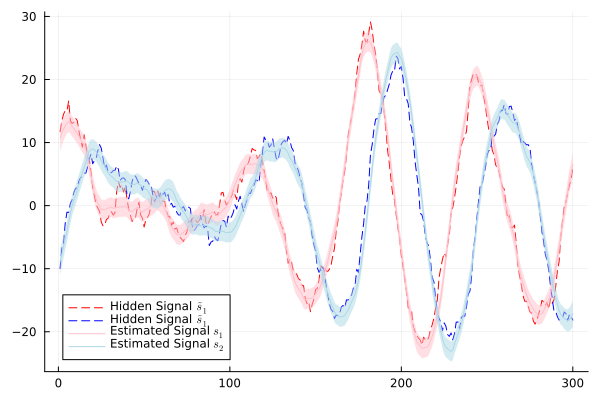

In [18]:
_p = plot()
_p = plot!(_p, getindex.(_s̃, 1), label="Hidden Signal " * L"\tilde{s}_1", color=:red, linestyle=:dash)
_p = plot!(_p, getindex.(_s̃, 2), label="Hidden Signal " * L"\tilde{s}_1", color=:blue, linestyle=:dash)

_p = plot!(_p, getindex.(mean.(_smarginals), 1), ribbon=getindex.(var.(_smarginals), 1) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"s_1", color=:pink)
_p = plot!(_p, getindex.(mean.(_smarginals), 2), ribbon=getindex.(var.(_smarginals), 2) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"s_2", color=:lightblue)
plot(_p)

As we can see from our plot, estimated signal resembles closely to the real hidden states with small variance. We maybe also interested in the value for minus log evidence:

In [19]:
_logevidence

1-element Vector{Float64}:
 -1882.2434870099428

## 2 System Identification Problem

In this example we are going to attempt to run Bayesian inference and decouple two random-walk signals, which were combined into a single through some deterministic function `f`. We do not have access to the real values of these signals, but only to their combination. First, we create the `sim_batch_data` function that accepts `f` as an argument:

In [20]:
#/// s₁,ₜ₋₁ = 7
# # s₁₍ₜ₋₁₎ = 8
# s₁,ₜ₋₁
# # s₁₍ₜ₋₁₎

The function returns the real signals `s̃₁` and  `s̃₂` for later comparison (we are not going to use them during inference) and their combined version `y` (we are going to use it as our observations during the inference). We also assume that `y` is corrupted with some measurement noise.

### Combination 1: $y = \tilde{s}_1 + \tilde{s}_2$

In our first example, we are going to use a simple addition (`+`) as the function `f`. In general, it is impossible to decouple the signals `s̃₁` and `s̃₂` without strong priors, but we can try and see how good an inference can be. The `+` operation on two random variables also has a special meaning in the probabilistic inference, namely the convolution of pdf's of the two random variables, and `RxInfer` treats it specially with many precomputed analytical rules, which may make the inference task easier. First, let us create a test dataset:

In [57]:
_s̃₁₍ₜ₋₁₎ = -20.0
_s̃₂₍ₜ₋₁₎ = 20.0
_τ̃_s₁ = 0.1
_τ̃_s₂ = 1.0
# _v = 20.0 ##observation noise
_σ̃²ᵥ = 20.0 ##observation noise
_T = 250


250

### Provision function ($f_p$)
The *provision* function, provides another covariate vector. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function:

$$\tilde{p}_{1t} = f_p(\tilde{s}_{1,t-1}) = \tilde{s}_{1,t-1}$$

$$\tilde{p}_{2t} = f_p(\tilde{s}_{2,t-1}) = \tilde{s}_{2,t-1}$$

$$\tilde{s}_{1t} = \mathcal{N}(\tilde{p}_{1t}, \tilde{\tau}_{s_1})$$

$$\tilde{s}_{2t} = \mathcal{N}(\tilde{p}_{2t}, \tilde{\tau}_{s_2})$$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [58]:
## provision function, provides another covariate vector
function fₚ(; s̃ₜ₋₁)
    return s̃ₜ₋₁
end
fₚ(s̃ₜ₋₁=_s̃₁₍ₜ₋₁₎), fₚ(s̃ₜ₋₁=_s̃₂₍ₜ₋₁₎) 

(-20.0, 20.0)

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector.
$$\tilde{r}_{t} = f_r(\tilde{s}_{1t}, \tilde{s}_{2t}) = f(\tilde{s}_{1t}, \tilde{s}_{2t}) = \tilde{s}_{1t} + \tilde{s}_{2t} $$

$$y_{t} = \mathcal{N}(\tilde{r}_{t}, \tilde{\sigma}^2_V)$$


The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [59]:
## response function, provides the response to covariate vector
function fᵣ(; f, s̃₁ₜ, s̃₂ₜ)
    # return s̃₁ₜ + s̃₂ₜ
    return f(s̃₁ₜ, s̃₂ₜ)
end
fᵣ(; f=+, s̃₁ₜ=7.0, s̃₂ₜ=8.0)

15.0

In [60]:
# function generate_data(f, T; seed=123, vₜ₋₁=-20.0, wₜ₋₁=20.0, noise=20.0, real_v_τ=0.1, real_w_τ=1.0) #.
# function sim_point_data(f, T; seed=123, s̃ᵛₜ₋₁=-20.0, s̃ʷₜ₋₁=20.0, noise=20.0, τ̃_sᵛ=0.1, τ̃_sʷ=1.0)
# function sim_point_data(f, T; seed=123, s̃₁₍ₜ₋₁₎=-20.0, s̃₂₍ₜ₋₁₎=20.0, τ̃₁=0.1, τ̃₂=1.0, v)
## batch is along 'time' dimension
# function sim_batch_data(f, T; seed=123, s̃₁₍ₜ₋₁₎=-20.0, s̃₂₍ₜ₋₁₎=20.0, τ̃_s₁=0.1, τ̃_s₂=1.0, σ̃²ᵥ)
# function sim_batch_data(f, T; seed=123, s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎, τ̃_s₁=0.1, τ̃_s₂=1.0, σ̃²ᵥ)
function sim_batch_data(f, T; seed=123, s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎, τ̃_s₁, τ̃_s₂, σ̃²ᵥ)
    # function sim_point_data(f, T; seed=123, s̃¹ₜ₋₁=-20.0, s̃²ₜ₋₁=20.0, noise=20.0, τ̃_sᵛ=0.1, τ̃_sʷ=1.0)
        rng = StableRNG(seed)
        # real_v = Vector{Float64}(undef, T)
        # s̃ᵛ = Vector{Float64}(undef, T)
        p̃₁ = Vector{Float64}(undef, T)
        s̃₁ = Vector{Float64}(undef, T)
        # real_w = Vector{Float64}(undef, T)
        # s̃ʷ = Vector{Float64}(undef, T)
        p̃₂ = Vector{Float64}(undef, T)
        s̃₂ = Vector{Float64}(undef, T)
        # real_y = Vector{Float64}(undef, T)
        r̃ = Vector{Float64}(undef, T)
        y = Vector{Float64}(undef, T)
        for t in 1:T
            # real_v[t] = rand(rng, Normal(vₜ₋₁, sqrt(1.0/real_v_τ)))
            # s̃ᵛ[t] = rand(rng, Normal(s̃ᵛₜ₋₁, sqrt(1.0/τ̃_sᵛ)))
            # s̃₁[t] = rand(rng, Normal(s̃₁₍ₜ₋₁₎, sqrt(1.0/τ̃₁)))
            p̃₁[t] = fₚ(s̃ₜ₋₁=s̃₁₍ₜ₋₁₎)
            # s̃₁[t] = rand(rng, Normal(s̃₁₍ₜ₋₁₎, sqrt(1.0/τ̃_s₁)))
            s̃₁[t] = rand(rng, Normal(p̃₁[t], sqrt(1.0/τ̃_s₁)))
            # real_w[t] = rand(rng, Normal(wₜ₋₁, sqrt(1.0/real_w_τ)))
            # s̃ʷ[t] = rand(rng, Normal(s̃ʷₜ₋₁, sqrt(1.0/τ̃_sʷ)))
            # s̃₂[t] = rand(rng, Normal(s̃₂₍ₜ₋₁₎, sqrt(1.0/τ̃₂)))
            p̃₂[t] = fₚ(s̃ₜ₋₁=s̃₂₍ₜ₋₁₎)
            # s̃₂[t] = rand(rng, Normal(s̃₂₍ₜ₋₁₎, sqrt(1.0/τ̃_s₂)))
            s̃₂[t] = rand(rng, Normal(p̃₂[t], sqrt(1.0/τ̃_s₂)))
            # real_y[t] = rand(rng, Normal(f(real_v[t], real_w[t]), sqrt(noise)))
            # y[t] = rand(rng, Normal(f(s̃ᵛ[t], s̃ʷ[t]), sqrt(noise)))
            # y[t] = rand(rng, Normal(f(s̃₁[t], s̃₂[t]), sqrt(v)))
            r̃[t] = fᵣ(f=f, s̃₁ₜ=s̃₁[t], s̃₂ₜ=s̃₂[t])
            # y[t] = rand(rng, Normal(f(s̃₁[t], s̃₂[t]), sqrt(σ̃²ᵥ)))
            y[t] = rand(rng, Normal(r̃[t], sqrt(σ̃²ᵥ)))
            # vₜ₋₁ = real_v[t]
            # s̃ᵛₜ₋₁ = s̃ᵛ[t]
            s̃₁₍ₜ₋₁₎ = s̃₁[t]
            # wₜ₋₁ = real_w[t]
            # s̃ʷₜ₋₁ = s̃ʷ[t]
            s̃₂₍ₜ₋₁₎ = s̃₂[t]
        end
        # return real_v, real_w, real_y
        # return s̃ᵛ, s̃ʷ, y
        return s̃₁, s̃₂, y
    end

sim_batch_data (generic function with 2 methods)

In [62]:
# _real_v, _real_w, _real_y = generate_data(+, _T);
# _real_v, _real_w, _real_y = sim_point_data(+, _T);
# _s̃ᵛ, _s̃ʷ, _y = sim_point_data(+, _T);
# _s̃ᵛ, _s̃ʷ, _y = sim_point_data(+, _T; v=_v);
# _s̃₁, _s̃₂, _y = sim_batch_data(+, _T; v=_v);
# _s̃₁, _s̃₂, _y = sim_batch_data(+, _T; σ²ᵥ=_σ̃²ᵥ);
# _s̃₁, _s̃₂, _y = sim_batch_data(+, _T; s̃₁₍ₜ₋₁₎=_s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎=_s̃₂₍ₜ₋₁₎, σ̃²ᵥ=_σ̃²ᵥ);
_s̃₁, _s̃₂, _y = sim_batch_data(
    +, _T; 
    s̃₁₍ₜ₋₁₎=_s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎=_s̃₂₍ₜ₋₁₎, 
    τ̃_s₁=_τ̃_s₁, τ̃_s₂=_τ̃_s₂, 
    σ̃²ᵥ=_σ̃²ᵥ);

In [63]:
# _real_v
# _s̃ᵛ
_s̃₁

250-element Vector{Float64}:
 -20.401095992460988
 -20.669875759133884
 -22.790697414814776
 -27.104638760134062
 -31.248220640067366
 -26.079608998684243
 -27.11512896946521
 -30.294795287103234
 -32.698280013763174
 -34.850070378118104
   ⋮
 -54.425338775704006
 -52.385873910242495
 -52.85091503729492
 -56.78914098796255
 -55.320201350025165
 -57.280441332339045
 -59.649902999048585
 -59.74600957488877
 -59.32390477663593

In [64]:
# _real_w
# _s̃ʷ
_s̃₂

250-element Vector{Float64}:
 20.666885172487124
 20.57261116763893
 19.857870775719412
 18.858298515749894
 19.81453408886256
 20.425064540658344
 19.918312704314683
 19.372737596030216
 18.846506733028683
 19.028263308009453
  ⋮
 52.195724854526475
 52.15806523930519
 50.846307575145
 51.655335116038906
 50.10235490650183
 50.4547248217021
 51.8221505241864
 49.89530546131343
 49.41021524826118

In [65]:
# _real_y
_y

250-element Vector{Float64}:
  -5.353952716032312
   4.275970805667579
  -7.258265483265913
 -14.918691611380964
  -2.2896811630057545
  -3.2075768172574284
  -2.5265011562304194
  -7.968874122573138
 -15.558887021638972
 -18.922064684720848
   ⋮
  -5.7302639800412
  -7.6087747572588595
   0.8729760214719842
  -8.777046520647438
  -6.96998099352899
  -8.267463283992118
  -1.8915218553802147
 -11.710160406427718
 -17.39194603977586

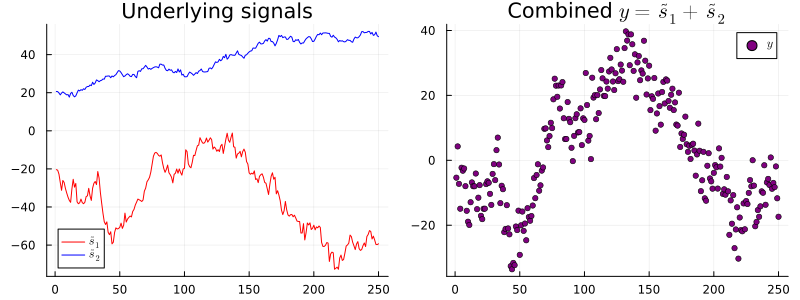

In [66]:
_pl = plot(title="Underlying signals")
# _pl = plot!(_pl, _real_v, label="v", c="red")
# _pl = plot!(_pl, _s̃ᵛ, label=L"\tilde{s}^v", c="red")
_pl = plot!(_pl, _s̃₁, label=L"\tilde{s}_1", c="red")

# _pl = plot!(_pl, _real_w, label="w", c="blue")
# _pl = plot!(_pl, _s̃ʷ, label=L"\tilde{s}^w", c="blue")
_pl = plot!(_pl, _s̃₂, label=L"\tilde{s}_2", c="blue")

# _pr = plot(title="Combined y = v + w")
# _pr = plot(title="Combined " * L"y = \tilde{s}^v + \tilde{s}^w")
_pr = plot(title="Combined " * L"y = \tilde{s}_1 + \tilde{s}_2")
# _pr = scatter!(_pr, _real_y, ms=3, color=:red, label="y")
_pr = scatter!(_pr, _y, ms=3, color=:purple, label=L"y")

plot(_pl, _pr, size=(800, 300))

To run inference, we need to create a probabilistic model: our beliefs about how our data could have been generated. For this we can use the `@model` macro from `RxInfer.jl`:

In [67]:
# @model function identification_problem(f, y, m_v_0, τ_v_0, a_v, b_v, m_w_0, τ_w_0, a_w, b_w, a_y, b_y)
@model function identification_problem(f, y, m₁₀, τ₁₀, a₁, b₁, m₂₀, τ₂₀, a₂, b₂, a_y, b_y)
    # v0 ~ Normal(mean=m_v_0, precision=τ_v_0)
    s₁₀ ~ Normal(mean=m₁₀, precision=τ₁₀)
    # τ_v ~ Gamma(shape=a_v, rate=b_v)
    # τ₁ ~ Gamma(shape=a₁, rate=b₁)
    τ_s₁ ~ Gamma(shape=a₁, rate=b₁)
    # w0 ~ Normal(mean=m_w_0, precision=τ_w_0)
    s₂₀ ~ Normal(mean=m₂₀, precision=τ₂₀)
    # τ_w ~ Gamma(shape=a_w, rate=b_w)
    # τ₂ ~ Gamma(shape=a₂, rate=b₂)
    τ_s₂ ~ Gamma(shape=a₂, rate=b₂)
    # τ_y ~ Gamma(shape=a_y, rate=b_y)
    τ_y ~ Gamma(shape=a_y, rate=b_y)

    # vₜ₋₁ = v0
    s₁₍ₜ₋₁₎ = s₁₀
    # wₜ₋₁ = w0
    s₂₍ₜ₋₁₎ = s₂₀
    # local v
    local s₁
    # local w
    local s₂
    local z
    for t in 1:length(y)
        # v[t] ~ Normal(mean=vₜ₋₁, precision=τ_v)
        # s₁[t] ~ Normal(mean=s₁₍ₜ₋₁₎, precision=τ₁)
        s₁[t] ~ Normal(mean=s₁₍ₜ₋₁₎, precision=τ_s₁)
        # w[t] ~ Normal(mean=wₜ₋₁, precision=τ_w)
        # s₂[t] ~ Normal(mean=s₂₍ₜ₋₁₎, precision=τ₂)
        s₂[t] ~ Normal(mean=s₂₍ₜ₋₁₎, precision=τ_s₂)
        # z[t] ~ f(v[t], w[t])
        z[t] ~ f(s₁[t], s₂[t])
        y[t] ~ Normal(mean=z[t], precision=τ_y)
        # vₜ₋₁ = v[t]
        s₁₍ₜ₋₁₎ = s₁[t]
        # wₜ₋₁ = w[t]
        s₂₍ₜ₋₁₎ = s₂[t]
    end
end

`RxInfer` runs Bayesian inference as a variational optimisation procedure between the real solution and its variational proxy `q`. In our model specification we assumed noise components to be unknown, thus, we need to enforce a structured mean-field assumption for the variational family of distributions `q`. This inevitably reduces the accuracy of the result, but makes the task easier and allows for fast and analytical message passing-based variational inference:

In [68]:
_constraints = @constraints begin
    # q(v0, w0, v, w, τ_v, τ_w, τ_y, z) = q(v, v0, w, w0, z)q(τ_w)q(τ_v)q(τ_y)
    # q(s₁₀, s₂₀, s₁, s₂, τ₁, τ₂, τ_y, z) = q(s₁, s₁₀, s₂, s₂₀, z)q(τ₂)q(τ₁)q(τ_y)
    q(s₁₀, s₂₀, s₁, s₂, τ_s₁, τ_s₂, τ_y, z) = q(s₁, s₁₀, s₂, s₂₀, z)q(τ_s₂)q(τ_s₁)q(τ_y)
end

Constraints: 
  q(s₁₀, s₂₀, s₁, s₂, τ_s₁, τ_s₂, τ_y, z) = q(s₁, s₁₀, s₂, s₂₀, z)q(τ_s₂)q(τ_s₁)q(τ_y)


The next step is to assign priors, initialise needed messages and marginals and call the `inference` function:

In [69]:
# _m_v_0, _τ_v_0 = -20.0, 1.0
_m₁₀, _τ₁₀ = -20.0, 1.0
# _m_w_0, _τ_w_0 = 20.0, 1.0
_m₂₀, _τ₂₀ = 20.0, 1.0

## We set relatively strong priors for random walk noise components
## and sort of vague prior for the noise of the observations
# _a_v, _b_v = 0.01, 0.01var(_real_v)
_a₁, _b₁ = 0.01, 0.01var(_s̃₁)
# _a_w, _b_w = 0.01, 0.01var(_real_w)
_a₂, _b₂ = 0.01, 0.01var(_s̃₂)
_a_y, _b_y = 1.0, 1.0

## We set relatively strong priors for messages
# _vinit = map(r -> NormalMeanPrecision(r, _τ_v_0), reverse(range(-60, -20, length=_T)))
_s₁_init = map(r -> NormalMeanPrecision(r, _τ₁₀), reverse(range(-60, -20, length=_T)))
# _winit = map(r -> NormalMeanPrecision(r, _τ_w_0), range(20, 60, length=_T))
_s₂_init = map(r -> NormalMeanPrecision(r, _τ₂₀), range(20, 60, length=_T))

_init = @initialization begin
    # μ(v) = _vinit
    μ(s₁) = _s₁_init
    # μ(w) = _winit
    μ(s₂) = _s₂_init
    # q(τ_v) = GammaShapeRate(_a_v, _b_v)
    q(τ_s₁) = GammaShapeRate(_a₁, _b₁)
    # q(τ_w) = GammaShapeRate(_a_w, _b_w)
    q(τ_s₂) = GammaShapeRate(_a₂, _b₂)
    q(τ_y) = GammaShapeRate(_a_y, _b_y)
end

# ntification_problem(f, y, m_v_0, τ_v_0, a_v, b_v, m_w_0, τ_w_0, a_w, b_w, a_y, b_y)
# ntification_problem(f, y, m₁₀, τ₁₀, a₁, b₁, m₂₀, τ₂₀, a₂, b₂, a_y, b_y)
_result = infer(
    # model = identification_problem(f=+, m_v_0=_m_v_0, τ_v_0=_τ_v_0, a_v=_a_v, b_v=_b_v, m_w_0=_m_w_0, τ_w_0=_τ_w_0, a_w=_a_w, b_w=_b_w, a_y=_a_y, b_y=_b_y),
    model = identification_problem(
        f=+, 
        m₁₀=_m₁₀, τ₁₀=_τ₁₀, a₁=_a₁, b₁=_b₁, 
        m₂₀=_m₂₀, τ₂₀=_τ₂₀, a₂=_a₂, b₂=_b₂, 
        a_y=_a_y, b_y=_b_y),
    # data  = (y = _real_y,), 
    data  = (y = _y,), 
    options = (limit_stack_depth = 500, ), 
    constraints = _constraints, 
    initialization = _init,
    iterations = 50
)

Inference results:
  Posteriors       | available for (s₂, τ_s₂, s₁₀, s₂₀, τ_s₁, s₁, z, τ_y)


In [70]:
_result.posteriors

Dict{Symbol, Vector} with 8 entries:
  :s₂   => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :τ_s₂ => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=125.01, b=129.061)…
  :s₁₀  => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{Flo…
  :s₂₀  => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{Flo…
  :τ_s₁ => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=125.01, b=132.021)…
  :s₁   => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :z    => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :τ_y  => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=126.0, b=262.02), …

Let's examine our inference results:

In [71]:
# _τ_v_marginals = _result.posteriors[:τ_v]
_τ_s₁_marginals = _result.posteriors[:τ_s₁]
# _τ_w_marginals = _result.posteriors[:τ_w]
_τ_s₂_marginals = _result.posteriors[:τ_s₂]
_τ_y_marginals = _result.posteriors[:τ_y]

# _zmarginals = _result.posteriors[:z]
_z_marginals = _result.posteriors[:z]
# _vmarginals = _result.posteriors[:v]
_s₁_marginals = _result.posteriors[:s₁]
# _wmarginals = _result.posteriors[:w];
_s₂_marginals = _result.posteriors[:s₂];

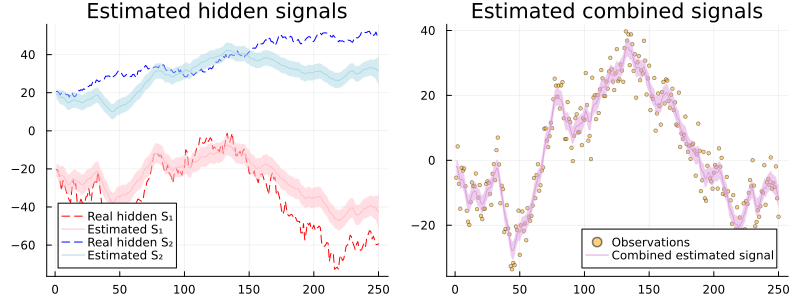

In [72]:
_p1 = plot(legend=:bottomleft, title="Estimated hidden signals")
_p2 = plot(legend=:bottomright, title="Estimated combined signals")

# _p1 = plot!(_p1, _real_v, label="Real hidden V")
# _p1 = plot!(_p1, _real_v, label="Real hidden V", c="red", linestyle=:dash)
_p1 = plot!(_p1, _s̃₁, label="Real hidden S₁", c="red", linestyle=:dash)
# _p1 = plot!(_p1, mean.(_vmarginals[end]), ribbon=var.(_vmarginals[end]), label="Estimated V")
# _p1 = plot!(_p1, mean.(_vmarginals[end]), ribbon=var.(_vmarginals[end]), label="Estimated V", color=:pink)
_p1 = plot!(_p1, mean.(_s₁_marginals[end]), ribbon=var.(_s₁_marginals[end]), label="Estimated S₁", color=:pink)

# _p1 = plot!(_p1, _real_w, label="Real hidden W")
# _p1 = plot!(_p1, _real_w, label="Real hidden W", color=:blue, linestyle=:dash)
_p1 = plot!(_p1, _s̃₂, label="Real hidden S₂", color=:blue, linestyle=:dash)
# _p1 = plot!(_p1, mean.(_wmarginals[end]), ribbon=var.(_wmarginals[end]), label="Estimated W")
# _p1 = plot!(_p1, mean.(_wmarginals[end]), ribbon=var.(_wmarginals[end]), label="Estimated W", color=:lightblue)
_p1 = plot!(_p1, mean.(_s₂_marginals[end]), ribbon=var.(_s₂_marginals[end]), label="Estimated S₂", color=:lightblue)

# _p2 = scatter!(_p2, _real_y, label="Observations", ms=2, alpha=0.5, color=:red)
# _p2 = scatter!(_p2, _real_y, label="Observations", ms=2, alpha=0.5, color=:orange)
_p2 = scatter!(_p2, _y, label="Observations", ms=2, alpha=0.5, color=:orange)
# _p2 = plot!(_p2, mean.(_zmarginals[end]), ribbon=std.(_zmarginals[end]), label="Combined estimated signal", color=:green)
# _p2 = plot!(_p2, mean.(_zmarginals[end]), ribbon=std.(_zmarginals[end]), label="Combined estimated signal", color="plum")
_p2 = plot!(_p2, mean.(_z_marginals[end]), ribbon=std.(_z_marginals[end]), label="Combined estimated signal", color="plum")

plot(_p1, _p2, size=(800, 300))

The inference results are not so bad, even though `RxInfer` missed the correct values of the signals between `100` and `150`.

### Combination 2: $y = \mathrm{min}(\tilde{s}_1, \tilde{s}_2)$

In this example we use a slightly more complex function, for which `RxInfer` does not have precomputed analytical message update rules. We are going to attempt to run Bayesian inference with `min` as a combination function. Note, however, that directly using `min` may cause problems for the built-in approximation methods as it has zero partial derviates with respect to all but one of the variables. We generate data with the `min` function directly however we model it with a somewhat smoothed version:

In [73]:
## Smoothed version of `min` without zero-ed derivatives
function smooth_min(x, y)    
    if x < y
        return x + 1e-4*y
    else
        return y + 1e-4*x
    end
end

smooth_min (generic function with 1 method)

`RxInfer` supports arbitrary nonlinear functions, but it requires an explicit approximation method specification. That can be achieved with the built-in `@meta` macro:

In [74]:
_min_meta = @meta begin 
    ## In this example we are going to use a simple `Linearization` method
    smooth_min() -> Linearization()
end

Meta: 
  smooth_min() -> Linearization()


In [75]:
_s̃₁₍ₜ₋₁₎ = 0.0
_s̃₂₍ₜ₋₁₎ = 0.0
_τ̃_s₁ = 1.0
_τ̃_s₂ = 1.0
_σ̃²ᵥ = 1.0 ##observation noise
_T = 200

200

In [76]:
# _min_real_v, _min_real_w, _min_real_y = generate_data(min, _T, seed=1, vₜ₋₁=0.0, wₜ₋₁=0.0, noise=1.0, real_v_τ=1.0, real_w_τ=1.0); #.
# _min_real_v, _min_real_w, _min_real_y = sim_point_data(min, _T, seed=1, vₜ₋₁=0.0, wₜ₋₁=0.0, noise=1.0, real_v_τ=1.0, real_w_τ=1.0); #.
# _min_s̃₁, _min_s̃₂, _min_y = sim_batch_data(
#     min, _T, 
#     seed=1, 
#     s̃₁₍ₜ₋₁₎=0.0, s̃₂₍ₜ₋₁₎=0.0, 
#     v=1.0, 
#     τ̃_s₁=1.0, τ̃_s₂=1.0); #.
_min_s̃₁, _min_s̃₂, _min_y = sim_batch_data(
    min, _T; 
    seed=1, 
    s̃₁₍ₜ₋₁₎=_s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎=_s̃₂₍ₜ₋₁₎, 
    τ̃_s₁=_τ̃_s₁, τ̃_s₂=_τ̃_s₂, 
    σ̃²ᵥ=_σ̃²ᵥ);

In [77]:
# _min_real_v
_min_s̃₁

200-element Vector{Float64}:
 -0.5325200748641231
 -1.3760574787383777
 -0.34376400643438854
 -0.09683736607523746
 -1.9500360726184451
 -1.7178925137280041
 -0.5114889405789891
  0.9799054887699994
  1.4738614452691385
  0.21583988918877006
  ⋮
 11.635994703121376
 10.924903891533114
 12.101086505558115
 12.23488278202865
 14.24470601685975
 16.68915952947985
 15.21355198384941
 17.49518040732118
 16.88853455216658

In [78]:
# _min_real_w
_min_s̃₂

200-element Vector{Float64}:
  0.098465514284785
 -1.9153638413463216
 -1.2397977422271311
 -2.740326889546081
 -3.0775177160930336
 -2.5211723474749315
 -3.1417645469162077
 -3.8175642158895347
 -3.403893528229725
 -3.944508580769285
  ⋮
  2.9447026640735814
  3.343236550774581
  1.7153229626545394
  3.1612860855506497
  3.464740837552133
  4.966929654823941
  5.590221124459778
  6.156878620294983
  5.219136120500052

In [79]:
# _min_real_y
_min_y

200-element Vector{Float64}:
  0.22036644726040033
 -2.1851714825434487
 -1.1576369146831669
 -2.411694880333956
 -3.0418551997138934
 -3.5489933567433987
 -2.529456341036421
 -4.568787926083518
 -2.8472451081518817
 -4.672624206001446
  ⋮
  2.7076738085196226
  3.5105327668426
  2.1476892369392173
  4.2435567676856065
  4.165753448418778
  3.584702727331395
  6.14602156701984
  7.5620630212942235
  6.086359625031924

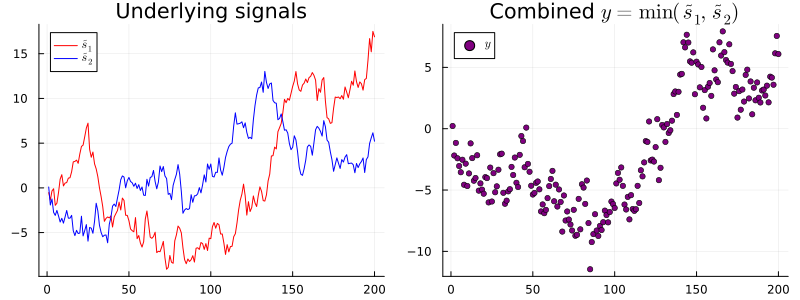

In [80]:
_pl = plot(title = "Underlying signals")
# _pl = plot!(_pl, _min_real_v, label = "v")
# _pl = plot!(_pl, _min_real_v, label = "v", c=:red)
_pl = plot!(_pl, _min_s̃₁, label=L"\tilde{s}_1", c=:red)

# _pl = plot!(_pl, _min_real_w, label = "w")
# _pl = plot!(_pl, _min_real_w, label = "w", c=:blue)
_pl = plot!(_pl, _min_s̃₂, label=L"\tilde{s}_2", c=:blue)

# _pr = plot(title = "Combined y = min(v, w)")
_pr = plot(title = "Combined " * L"y = \mathrm{min}(\tilde{s}_1, \tilde{s}_2)")
# _pr = scatter!(_pr, _min_real_y, ms= 3, color= :red, label= "y")
# _pr = scatter!(_pr, _min_real_y, ms= 3, color= :purple, label= "y")
_pr = scatter!(_pr, _min_y, ms=3, color=:purple, label=L"y")

plot(_pl, _pr, size = (800, 300))

In [81]:
# _min_m_v_0, _min_τ_v_0 = -1.0, 1.0
_min_m₁₀, _min_τ₁₀ = -1.0, 1.0
# _min_m_w_0, _min_τ_w_0 = 1.0, 1.0
_min_m₂₀, _min_τ₂₀ = 1.0, 1.0

# _min_a_v, _min_b_v = 1.0, 1.0
_min_a₁, _min_b₁ = 1.0, 1.0
# _min_a_w, _min_b_w = 1.0, 1.0
_min_a₂, _min_b₂ = 1.0, 1.0
_min_a_y, _min_b_y = 1.0, 1.0

_init = @initialization begin
    # μ(v) = NormalMeanPrecision(_min_m_v_0, _min_τ_v_0)
    μ(s₁) = NormalMeanPrecision(_min_m₁₀, _min_τ₁₀)
    # μ(w) = NormalMeanPrecision(_min_m_w_0, _min_τ_w_0)
    μ(s₂) = NormalMeanPrecision(_min_m₂₀, _min_τ₂₀)
    # q(τ_v) = GammaShapeRate(_min_a_v, _min_b_v)
    q(τ_s₁) = GammaShapeRate(_min_a₁, _min_b₁)
    # q(τ_w) = GammaShapeRate(_min_a_w, _min_b_w)
    q(τ_s₂) = GammaShapeRate(_min_a₂, _min_b₂)
    q(τ_y) = GammaShapeRate(_min_a_y, _min_b_y)
end

# ntification_problem(f, y, m_v_0, τ_v_0, a_v, b_v, m_w_0, τ_w_0, a_w, b_w, a_y, b_y)
# ntification_problem(f, y, m₁₀, τ₁₀, a₁, b₁, m₂₀, τ₂₀, a₂, b₂, a_y, b_y)
_min_result = infer(
    model = identification_problem(
        # f=smooth_min, 
        # m_v_0=_min_m_v_0, τ_v_0=_min_τ_v_0, a_v=_min_a_v, b_v=_min_b_v, 
        # m_w_0=_min_m_w_0, τ_w_0=_min_τ_w_0, a_w=_min_a_w, b_w=_min_b_w, 
        # a_y=_min_a_y, b_y=_min_b_y),
        f=smooth_min, 
        m₁₀=_min_m₁₀, τ₁₀=_min_τ₁₀, a₁=_min_a₁, b₁=_min_b₁, 
        m₂₀=_min_m₂₀, τ₂₀=_min_τ₂₀, a₂=_min_a₂, b₂=_min_b₂, 
        a_y=_min_a_y, b_y=_min_b_y),
    # data  = (y = _min_real_y,), 
    data  = (y = _min_y,), 
    options = (limit_stack_depth = 500, ), 
    constraints = _constraints, 
    initialization = _init,
    meta = _min_meta,
    iterations = 50
)

Inference results:
  Posteriors       | available for (s₂, τ_s₂, s₁₀, s₂₀, τ_s₁, s₁, z, τ_y)


In [82]:
_min_result.posteriors

Dict{Symbol, Vector} with 8 entries:
  :s₂   => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :τ_s₂ => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=101.0, b=51.2907),…
  :s₁₀  => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{Flo…
  :s₂₀  => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{Flo…
  :τ_s₁ => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=101.0, b=51.2789),…
  :s₁   => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :z    => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :τ_y  => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=101.0, b=200.195),…

In [83]:
# _min_τ_v_marginals = _min_result.posteriors[:τ_v]
_min_τ_s₁_marginals = _min_result.posteriors[:τ_s₁]
# _min_τ_w_marginals = _min_result.posteriors[:τ_w]
_min_τ_s₂_marginals = _min_result.posteriors[:τ_s₂]
_min_τ_y_marginals = _min_result.posteriors[:τ_y]

# _min_zmarginals = _min_result.posteriors[:z]
_min_z_marginals = _min_result.posteriors[:z]
# _min_vmarginals = _min_result.posteriors[:v]
_min_s₁_marginals = _min_result.posteriors[:s₁]
# _min_wmarginals = _min_result.posteriors[:w];
_min_s₂_marginals = _min_result.posteriors[:s₂];

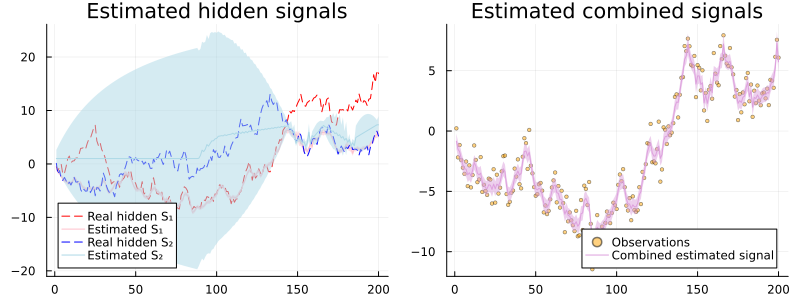

In [84]:
_p1 = plot(legend=:bottomleft, title="Estimated hidden signals")
_p2 = plot(legend=:bottomright, title="Estimated combined signals")

# _p1 = plot!(_p1, _min_real_v, label="Real hidden V")
# _p1 = plot!(_p1, _min_real_v, label="Real hidden V", c=:red, linestyle=:dash)
_p1 = plot!(_p1, _min_s̃₁, label="Real hidden S₁", c="red", linestyle=:dash)
# _p1 = plot!(_p1, mean.(_min_vmarginals[end]), ribbon=var.(_min_vmarginals[end]), label="Estimated V")
# _p1 = plot!(_p1, mean.(_min_vmarginals[end]), ribbon=var.(_min_vmarginals[end]), label="Estimated V", c=:pink)
_p1 = plot!(_p1, mean.(_min_s₁_marginals[end]), ribbon=var.(_min_s₁_marginals[end]), label="Estimated S₁", color=:pink)

# _p1 = plot!(_p1, _min_real_w, label="Real hidden W")
# _p1 = plot!(_p1, _min_real_w, label="Real hidden W", c=:blue, linestyle=:dash)
_p1 = plot!(_p1, _min_s̃₂, label="Real hidden S₂", color=:blue, linestyle=:dash)
# _p1 = plot!(_p1, mean.(_min_wmarginals[end]), ribbon=var.(_min_wmarginals[end]), label="Estimated W")
# _p1 = plot!(_p1, mean.(_min_wmarginals[end]), ribbon=var.(_min_wmarginals[end]), label="Estimated W", c=:lightblue)
_p1 = plot!(_p1, mean.(_min_s₂_marginals[end]), ribbon=var.(_min_s₂_marginals[end]), label="Estimated S₂", color=:lightblue)

# _p2 = scatter!(_p2, _min_real_y, label="Observations", ms=2, alpha=0.5, color=:red)
# _p2 = scatter!(_p2, _min_real_y, label="Observations", ms=2, alpha=0.5, color=:orange)
_p2 = scatter!(_p2, _min_y, label="Observations", ms=2, alpha=0.5, color=:orange)
# _p2 = plot!(_p2, mean.(_min_zmarginals[end]), ribbon=std.(_min_zmarginals[end]), label="Combined estimated signal", color=:green)
# _p2 = plot!(_p2, mean.(_min_zmarginals[end]), ribbon=std.(_min_zmarginals[end]), label="Combined estimated signal", color=:plum)
_p2 = plot!(_p2, mean.(_min_z_marginals[end]), ribbon=std.(_min_z_marginals[end]), label="Combined estimated signal", color="plum")

plot(_p1, _p2, size=(800, 300))

As we can see inference with the `min` function is significantly harder. Even though the combined signal has been inferred with high precision the underlying `v` and `w` signals are barely inferred. This may be expected, since the `min` function essentially destroy the information about one of the signals, thus, making it impossible to decouple two seemingly identical random walk signals. The only one inferred signal is the one which is lower and we have no inference information about the signal which is above. It might be possible to infer the states, however, with more informative priors and structural information about two different signals (e.g. if these are not random walks). 

### Online (filtering) identification: $y = \mathrm{min}(\tilde{s}_1, \tilde{s}_2)$

Another way to approach to this problem is to use online (filtering) inference procedure from `RxInfer`, but for that we also need to modify our model specification a bit:

Next step is to generate our dataset and to run the actual inference procedure! For that we use the `infer` function with `autoupdates` keyword:

In [85]:
_s̃₁₍ₜ₋₁₎ = 1.0
_s̃₂₍ₜ₋₁₎ = -1.0
_τ̃_s₁ = 1.0
_τ̃_s₂ = 1.0
_σ̃²ᵥ = 1.0 ##observation noise
# n = 300
_T = 300

300

In [86]:
# _rx_real_v, _rx_real_w, _rx_real_y = generate_data(min, _T, seed=1, vₜ₋₁=1.0, wₜ₋₁=-1.0, noise=1.0, real_v_τ=1.0, real_w_τ=1.0);
# _rx_real_v, _rx_real_w, _rx_real_y = sim_point_data(min, _T, seed=1, vₜ₋₁=1.0, wₜ₋₁=-1.0, noise=1.0, real_v_τ=1.0, real_w_τ=1.0);
# _rx_s̃₁, _rx_s̃₂, _rx_y = sim_batch_data(
#     min, _T, 
#     seed=1, 
#     s̃₁₍ₜ₋₁₎=1.0, s̃₂₍ₜ₋₁₎=-1.0, 
#     v=1.0, 
#     τ̃_s₁=1.0, τ̃_s₂=1.0); #.
_rx_s̃₁, _rx_s̃₂, _rx_y = sim_batch_data(
    min, _T; 
    seed=1, 
    s̃₁₍ₜ₋₁₎=_s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎=_s̃₂₍ₜ₋₁₎, 
    τ̃_s₁=_τ̃_s₁, τ̃_s₂=_τ̃_s₂, 
    σ̃²ᵥ=_σ̃²ᵥ);

In [87]:
# _rx_real_v
_rx_s̃₁

300-element Vector{Float64}:
  0.4674799251358769
 -0.3760574787383777
  0.6562359935656115
  0.9031626339247625
 -0.9500360726184451
 -0.7178925137280042
  0.4885110594210108
  1.9799054887699992
  2.4738614452691383
  1.2158398891887698
  ⋮
 14.715705062022895
 15.13350407386025
 14.966386749228318
 15.005789040066146
 14.522153754344416
 13.542981339795244
 14.554317190702813
 12.879159788609714
 12.533966078243003

In [88]:
# _rx_real_w
_rx_s̃₂

300-element Vector{Float64}:
  -0.901534485715215
  -2.9153638413463216
  -2.239797742227131
  -3.740326889546081
  -4.077517716093034
  -3.521172347474932
  -4.1417645469162085
  -4.8175642158895355
  -4.403893528229726
  -4.944508580769286
   ⋮
  -3.127596543119536
  -2.4904468534292046
  -2.41950024394849
  -2.8024522739003057
  -5.079038511589717
  -6.533981992409512
  -9.158210504701648
 -10.071390396703338
 -10.363573258463711

In [89]:
# _rx_real_y
_rx_y

300-element Vector{Float64}:
  -0.14864796359069155
  -3.1851714825434487
  -2.1576369146831667
  -3.411694880333956
  -4.041855199713893
  -4.5489933567433996
  -3.529456341036422
  -5.568787926083519
  -3.8472451081518826
  -5.672624206001447
   ⋮
  -0.8757311338953824
  -1.7386965707479658
  -1.7192256893794404
  -2.799924492306463
  -3.534637117106459
  -5.694563357428694
 -10.969410855554415
  -9.983476577762598
 -11.66386107476468

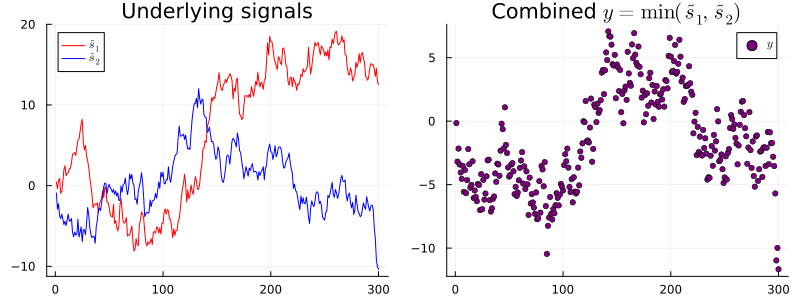

In [90]:
_pl = plot(title="Underlying signals")
# _pl = plot!(_pl, _rx_real_v, label="v")
# _pl = plot!(_pl, _rx_real_v, label="v", c=:red)
_pl = plot!(_pl, _rx_s̃₁, label=L"\tilde{s}_1", c=:red)

# _pl = plot!(_pl, _rx_real_w, label="w")
# _pl = plot!(_pl, _rx_real_w, label="w", c=:blue)
_pl = plot!(_pl, _rx_s̃₂, label=L"\tilde{s}_2", c=:blue)

# _pr = plot(title="Combined y = min(v, w)")
_pr = plot(title = "Combined " * L"y = \mathrm{min}(\tilde{s}_1, \tilde{s}_2)")
# _pr = scatter!(_pr, _rx_real_y, ms=3, color=:red, label="y")
# _pr = scatter!(_pr, _rx_real_y, ms=3, color=:purple, label="y")
_pr = scatter!(_pr, _rx_y, ms=3, color=:purple, label=L"y")

plot(_pl, _pr, size=(800, 300))

Another way to approach to this problem is to use online (filtering) inference procedure from `RxInfer`, but for that we also need to modify our model specification a bit:

In [91]:
# @model function rx_identification(f, m_v_0, τ_v_0, m_w_0, τ_w_0, a_v, b_v, a_y, b_y, a_w, b_w, y)
# @model function rx_identification(f, m₁₀, τ₁₀, m₂₀, τ₂₀, a₁, b₁, a_y, b_y, a₂, b₂, y)
@model function rx_identification(f, y, m₁₀, τ₁₀, a₁, b₁, m₂₀, τ₂₀, a₂, b₂, a_y, b_y)
    ## We are going to continuosly update our priors
    ## based on new posteriors

    # v0 ~ Normal(mean= m_v_0, precision= τ_v_0)
    s₁₀ ~ Normal(mean=m₁₀, precision=τ₁₀)
    # τ_v ~ Gamma(shape= a_v, rate= b_v)
    τ_s₁ ~ Gamma(shape=a₁, rate=b₁)
    # w0 ~ Normal(mean = m_w_0, precision = τ_w_0)
    s₂₀ ~ Normal(mean=m₂₀, precision=τ₂₀)
    # τ_w ~ Gamma(shape = a_w, rate = b_w)
    τ_s₂ ~ Gamma(shape=a₂, rate=b₂)
    # τ_y ~ Gamma(shape = a_y, rate = b_y)
    τ_y ~ Gamma(shape=a_y, rate=b_y)
    
    # v ~ Normal(mean= v0, precision= τ_v)
    s₁ ~ Normal(mean= s₁₀, precision= τ_s₁)
    # w ~ Normal(mean = w0, precision = τ_w)
    s₂ ~ Normal(mean = s₂₀, precision = τ_s₂)

    # z := f(v, w)
    z ~ f(s₁, s₂)
    y ~ Normal(mean=z, precision=τ_y)
end

We impose structured mean-field assumption for this model as well:

In [92]:
_rx_constraints = @constraints begin
    # q(v0, v, w0, w, τ_v, τ_w, τ_y, z) = q(v0, v)q(w, w0)q(τ_w)q(τ_v)q(z)q(τ_y)
    q(s₁₀, s₁, s₂₀, s₂, τ_s₁, τ_s₂, τ_y, z) = q(s₁₀, s₁)q(s₂, s₂₀)q(τ_s₂)q(τ_s₁)q(z)q(τ_y)
end

Constraints: 
  q(s₁₀, s₁, s₂₀, s₂, τ_s₁, τ_s₂, τ_y, z) = q(s₁₀, s₁)q(s₂, s₂₀)q(τ_s₂)q(τ_s₁)q(z)q(τ_y)


Online inference in the `RxInfer` supports the `@autoupdates` specification, which tells inference procedure how to update priors based on new computed posteriors:

In [93]:
_autoupdates = @autoupdates begin
    # m_v_0, τ_v_0 = mean_precision(q(v))
    m₁₀, τ₁₀ = mean_precision(q(s₁))
    # m_w_0, τ_w_0 = mean_precision(q(w))
    m₂₀, τ₂₀ = mean_precision(q(s₂))
    # a_v = shape(q(τ_v))
    a₁ = shape(q(τ_s₁))
    # b_v = rate(q(τ_v))
    b₁ = rate(q(τ_s₁))
    a_y = shape(q(τ_y))
    b_y = rate(q(τ_y))
    # a_w = shape(q(τ_w))
    a₂ = shape(q(τ_s₂)) 
    # b_w = rate(q(τ_w))
    b₂ = rate(q(τ_s₂))
end

(m₁₀,τ₁₀ = mean_precision(q(s₁)), m₂₀,τ₂₀ = mean_precision(q(s₂)), a₁ = shape(q(τ_s₁)), b₁ = rate(q(τ_s₁)), a_y = shape(q(τ_y)), b_y = rate(q(τ_y)), a₂ = shape(q(τ_s₂)), b₂ = rate(q(τ_s₂)))

As previously we need to define the `@meta` structure that specifies the approximation method for the nonlinear function `smooth_min` (`f` in the model specification):

In [94]:
_rx_meta = @meta begin 
    smooth_min() -> Linearization()
end

Meta: 
  smooth_min() -> Linearization()


///Next step is to generate our dataset and to run the actual inference procedure! For that we use the `infer` function with `autoupdates` keyword:

In [95]:
_init = @initialization begin
    # q(v) = NormalMeanVariance(2.0, 1.0)
    q(s₁) = NormalMeanVariance(2.0, 1.0)
    # q(w)= NormalMeanVariance(-2.0, 1.0)
    q(s₂)= NormalMeanVariance(-2.0, 1.0)
    # q(τ_v) = GammaShapeRate(1.0, 1.0) 
    q(τ_s₁) = GammaShapeRate(1.0, 1.0) 
    # q(τ_w) = GammaShapeRate(1.0, 1.0) 
    q(τ_s₂) = GammaShapeRate(1.0, 1.0) 
    q(τ_y) = GammaShapeRate(1.0, 20.0)
end

_engine = infer(
    model         = rx_identification(f=smooth_min),
    constraints   = _rx_constraints,
    # data          = (y = _rx_real_y,),
    data          = (y = _rx_y,),
    autoupdates   = _autoupdates,
    meta          = _rx_meta,
    # returnvars    = (:v, :w, :τ_v, :τ_w, :τ_y, :z),
    returnvars    = (:s₁, :s₂, :τ_s₁, :τ_s₂, :τ_y, :z),
    keephistory   = 1000,
    historyvars   =  KeepLast(),
    initialization = _init,
    iterations    = 10,
    free_energy = true, 
    free_energy_diagnostics = nothing,
    autostart     = true,
)

RxInferenceEngine:
  Posteriors stream    | enabled for (s₂, τ_s₂, τ_s₁, s₁, z, τ_y)
  Free Energy stream   | enabled
  Posteriors history   | available for (s₂, τ_s₂, s₁₀, s₂₀, τ_s₁, s₁, z, τ_y)
  Free Energy history  | available
  Enabled events       | [  ]

In [96]:
_engine.posteriors

Dict{Symbol, ProxyObservable{Any, Rocket.ScheduledSource{Marginal, PendingScheduler, ProxyObservable{Marginal, ReactiveMP.MarginalObservable, Rocket.FilterProxy{ReactiveMP.var"#31#32"}}}, Rocket.MapProxy{Marginal, RxInfer.var"#213#229"{DefaultPostprocess}}}} with 6 entries:
  :s₂   => ProxyObservable(Any, MapProxy(Marginal))
  :τ_s₂ => ProxyObservable(Any, MapProxy(Marginal))
  :τ_s₁ => ProxyObservable(Any, MapProxy(Marginal))
  :s₁   => ProxyObservable(Any, MapProxy(Marginal))
  :z    => ProxyObservable(Any, MapProxy(Marginal))
  :τ_y  => ProxyObservable(Any, MapProxy(Marginal))

In [97]:
# _rx_zmarginals = _engine.history[:z]
_rx_z_marginals = _engine.history[:z]
# _rx_vmarginals = _engine.history[:v]
_rx_s₁_marginals = _engine.history[:s₁]
# _rx_wmarginals = _engine.history[:w];
_rx_s₂_marginals = _engine.history[:s₂];

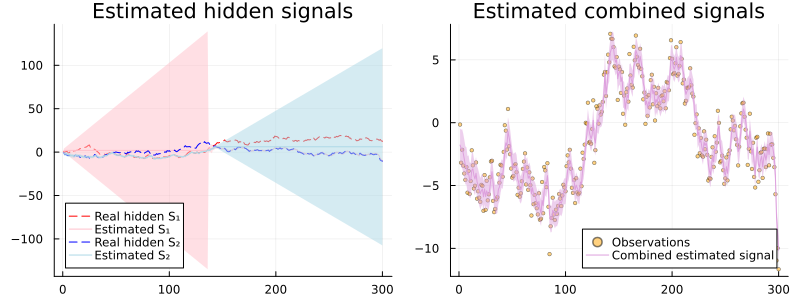

In [98]:
_p1 = plot(legend=:bottomleft, title="Estimated hidden signals")
_p2 = plot(legend=:bottomright, title="Estimated combined signals")

# _p1 = plot!(_p1, _rx_real_v, label="Real hidden V")
# _p1 = plot!(_p1, _rx_real_v, label="Real hidden V", c=:red, linestyle=:dash)
_p1 = plot!(_p1, _rx_s̃₁, label="Real hidden S₁", c=:red, linestyle=:dash)
# _p1 = plot!(_p1, mean.(_rx_vmarginals), ribbon=var.(_rx_vmarginals), label="Estimated V")
# _p1 = plot!(_p1, mean.(_rx_vmarginals), ribbon=var.(_rx_vmarginals), label="Estimated V", c=:pink)
_p1 = plot!(_p1, mean.(_rx_s₁_marginals), ribbon=var.(_rx_s₁_marginals), label="Estimated S₁", c=:pink)

# _p1 = plot!(_p1, _rx_real_w, label="Real hidden W")
# _p1 = plot!(_p1, _rx_real_w, label="Real hidden W", c=:blue, linestyle=:dash)
_p1 = plot!(_p1, _rx_s̃₂, label="Real hidden S₂", c=:blue, linestyle=:dash)
# _p1 = plot!(_p1, mean.(_rx_wmarginals), ribbon=var.(_rx_wmarginals), label="Estimated W")
# _p1 = plot!(_p1, mean.(_rx_wmarginals), ribbon=var.(_rx_wmarginals), label="Estimated W", c=:lightblue)
_p1 = plot!(_p1, mean.(_rx_s₂_marginals), ribbon=var.(_rx_s₂_marginals), label="Estimated S₂", c=:lightblue)

# _p2 = scatter!(_p2, _rx_real_y, label="Observations", ms=2, alpha=0.5, color=:red)
# _p2 = scatter!(_p2, _rx_real_y, label="Observations", ms=2, alpha=0.5, color=:orange)
_p2 = scatter!(_p2, _rx_y, label="Observations", ms=2, alpha=0.5, color=:orange)
# _p2 = plot!(_p2, mean.(_rx_zmarginals), ribbon=std.(_rx_zmarginals), label="Combined estimated signal", color=:green)
# _p2 = plot!(_p2, mean.(_rx_zmarginals), ribbon=std.(_rx_zmarginals), label="Combined estimated signal", color=:plum)
_p2 = plot!(_p2, mean.(_rx_z_marginals), ribbon=std.(_rx_z_marginals), label="Combined estimated signal", color=:plum)

plot(_p1, _p2, size=(800, 300))

The results are quite similar to the smoothing case and, as we can see, one of the random walk is again in the "disabled" state, does not infer anything and simply increases its variance (which is expected for the random walk).

## 3 Handling Missing Data

An interesting case in filtering and smoothing problems is the processing of missing data. It can happen that sometimes your reading devices fail to acquire the data leading to missing observation.

Let us assume that the following model generates the data

$$\begin{aligned}
    {s}_t &\sim \mathcal{N}\left({s}_{t-1}, w\right) \\
    {y}_t &\sim \mathcal{N}\left({s}_{t}, v \right) 
\end{aligned}$$
where $w = 1.0$

with prior ${s}_0 \sim \mathcal{N}({m_{{s}_0}}, {v_{{s}_0}})$. Suppose that our measurement device fails to acquire data from time to time.  In this case, instead of scalar observation $y_t \in \mathcal{R}$ we sometimes will catch `missing` observations.

In [136]:
# _P = 1.0
## _w = 1.0
_μᵥᵥ = 0.0
# _σ²ᵥᵥ = 0.0
# _σ²ᵥᵥ = 1.0
_σ²ᵥᵥ = 0.1

# _v = 1.0
# _v² = 1.0
_μᵥ = 0.0
_σ²ᵥ = 1.0
_T = 250
_missing_indices = 100:125

100:125

### Provision function ($f_p$)
The *provision* function, provides another covariate vector. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function:

$$\tilde{p}_{t} = f_{p}(t) = t$$
$$\tilde{s}_{t} = f_{p}(t) + w = \tilde{p}_{t} + w$$

where

$w \sim \mathcal{N}(\mu_W, \sigma^2_W)$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [137]:
## provision function, provides next batch of covariate vectors
## covariate vector here is just a scalar
function fₚ(;T)
    # return float.(collect(start:step:stop))
    ## tmp = float.(collect(1:N))
    ## return [[i] for i in tmp]
    p̃ₜ = float.(collect(1:T))
    return p̃ₜ
end
myp̃ₜ = fₚ(T=5)

5-element Vector{Float64}:
 1.0
 2.0
 3.0
 4.0
 5.0

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector.
$$\tilde{r}_{t} = f_{r}(\tilde{s}_{t}) = \mathrm{sin}(0.05t)$$
$$y_{t} = f_{r}(\tilde{s}_{t}) + v = \tilde{r}_{t} + v$$
where

$v \sim \mathcal{N}(\mu_V, \sigma^2_V)$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [138]:
## response function, provides next batch of responses to covariate vectors
## covariate vector here is just a scalar
# function g(a, b, x)
function fᵣ(s̃)
    # return β̃₁ .* s  .+  β̃₀
    ## return [a*i[1] + b for i in x]

    # r̃ₜ = map(t -> sin(0.05*t), s̃)
    r̃ₜ = sin.(0.05*s̃)
    return r̃ₜ
end
fᵣ(myp̃ₜ)

5-element Vector{Float64}:
 0.04997916927067833
 0.09983341664682815
 0.14943813247359924
 0.19866933079506122
 0.24740395925452294

In [139]:
## sim|lab OR fld _ batch OR point|obser
## batch is along 'depth/examples' dimension
## batch is along 'time' dimension
function sim_batch_data(rng, T, μᵥᵥ, σ²ᵥᵥ, μᵥ, σ²ᵥ) ## simulated batch data
    # _real_signal     = map(e -> sin(0.05 * e), collect(1:_T))
    # _p̃ₜ     = map(e -> sin(0.05 * e), collect(1:_T)) ## from provision function fₚ()
    # _s̃ₜ = map(t -> sin(0.05*t), collect(1:_T)) ## from provision function fₚ()
    # _p̃ₜ = map(t -> sin(0.05*t), collect(1:_T)) ## from provision function fₚ()
    p̃ₜ = fₚ(T=T) #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    w = rand(Normal(μᵥᵥ, sqrt(σ²ᵥᵥ)), T)
    s̃ₜ = p̃ₜ + w
    # _s̃ₜ = _p̃ₜ

    # _noisy_data      = _real_signal + rand(Normal(0.0, sqrt(_P)), _T);
    # _noisy_data      = _real_signal + rand(Normal(0.0, sqrt(_v)), _T);
    # _noisy_data      = _s̃ₜ + rand(Normal(0.0, sqrt(_v)), _T);
    # _s̃ₜ = _p̃ₜ + rand(Normal(0.0, sqrt(_v)), _T);
    # _yₜ = _p̃ₜ + rand(Normal(0.0, sqrt(_v)), _T);
    # _yₜ = _s̃ₜ + rand(Normal(0.0, sqrt(_v)), _T);
    # _yₜ = _s̃ₜ + rand(Normal(0.0, sqrt(_v²)), _T);
    # _r̃ₜ = _s̃ₜ
    r̃ₜ = fᵣ(s̃ₜ) #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    v = rand(Normal(μᵥ, sqrt(σ²ᵥ)), T)
    # _yₜ = _s̃ₜ + rand(Normal(_μᵥ, sqrt(_σ²ᵥ)), _T);
    yₜ = r̃ₜ + v

    # _missing_indices = 100:125
    # _missing_data    = similar(_noisy_data, Union{Float64, Missing}, )
    # _missing_data    = similar(_s̃ₜ, Union{Float64, Missing}, )
    # _s̃ₜ_missing    = similar(_s̃ₜ, Union{Float64, Missing}, )
    yₜ_missing    = similar(yₜ, Union{Float64, Missing}, )

    # copyto!(_missing_data, _noisy_data)
    # copyto!(_s̃ₜ_missing, _s̃ₜ)
    copyto!(yₜ_missing, yₜ)

    for index in _missing_indices
        # _missing_data[index] = missing
        # _s̃ₜ_missing[index] = missing
        yₜ_missing[index] = missing
    end
    return p̃ₜ, s̃ₜ, r̃ₜ, yₜ, yₜ_missing
end

sim_batch_data (generic function with 2 methods)

In [140]:
_p̃ₜ, _s̃ₜ, _r̃ₜ, _yₜ, _yₜ_missing = sim_batch_data(
    _rng, _T, 
    _μᵥᵥ, _σ²ᵥᵥ, 
    _μᵥ, _σ²ᵥ);

In [141]:
_s̃ₜ

250-element Vector{Float64}:
   1.2506958297641693
   1.6345783702942556
   3.536455458682867
   4.02606680467079
   4.830993950517589
   6.305651482165767
   6.873687705711373
   7.31409677496247
   8.876694109530899
  10.153551483604813
   ⋮
 241.84852620618585
 243.23524850901333
 244.55376073036243
 244.69570657553484
 245.74583272218808
 246.8203716645501
 247.95780666897426
 248.53893196199328
 250.14589079004705

In [142]:
_yₜ

250-element Vector{Float64}:
  1.408759553830695
  1.3348205065567205
  1.2539590839966992
 -0.32455710296932677
  0.5242913177247217
  2.0217863139519547
  0.4826164203392418
  2.8783929803548634
  1.8781540660768896
  0.14827453763297316
  ⋮
 -0.9523725018520959
 -1.1630524329102658
 -0.8082687238875373
  0.8917292728255298
 -0.24485603221286892
 -1.2280299939842263
 -1.5343381356345036
  3.029273532561164
 -1.1341366740297971

In [143]:
_s̃ₜ

250-element Vector{Float64}:
   1.2506958297641693
   1.6345783702942556
   3.536455458682867
   4.02606680467079
   4.830993950517589
   6.305651482165767
   6.873687705711373
   7.31409677496247
   8.876694109530899
  10.153551483604813
   ⋮
 241.84852620618585
 243.23524850901333
 244.55376073036243
 244.69570657553484
 245.74583272218808
 246.8203716645501
 247.95780666897426
 248.53893196199328
 250.14589079004705

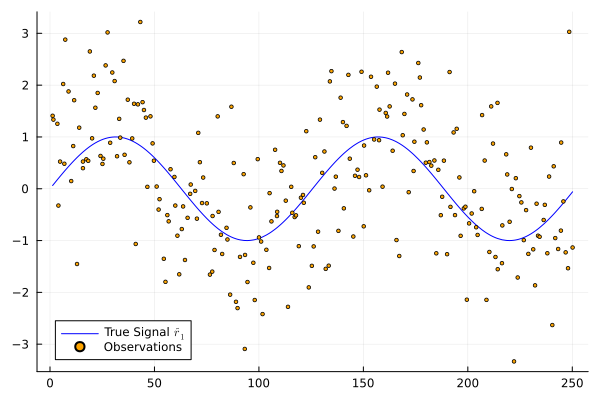

In [151]:
_p = plot()
_p = plot(_p, _s̃ₜ, _r̃ₜ, label="True Signal " * L"\tilde{r}_1", color=:blue)
_p = scatter!(_p, _s̃ₜ, _yₜ, label="Observations", markersize=2, color=:orange)

plot(_p)

In [129]:
# @model function smoothing(x0, y)
# @model function smoothing(x₀, y)
# @model function smoothing(y, x₀)
@model function smoothing(y, s₀)
    # P ~ Gamma(shape=0.001, scale=0.001)
    v ~ Gamma(shape=0.001, scale=0.001)
    # x_prior ~ Normal(mean=mean(x0), var=var(x0))
    # x_prior ~ Normal(mean=mean(x₀), var=var(x₀))
    s_prior ~ Normal(mean=mean(s₀), var=var(s₀))
    # local x
    local s
    # xₜ₋₁ = x_prior
    sₜ₋₁ = s_prior
    for t in 1:length(y)
        # x[t] ~ Normal(mean=xₜ₋₁, precision=1.0) #.
        s[t] ~ Normal(mean=sₜ₋₁, precision=1.0) #.
        # y[t] ~ Normal(mean=x[t], precision=P)
        # y[t] ~ Normal(mean=x[t], precision=v)
        y[t] ~ Normal(mean=s[t], precision=v)
        # xₜ₋₁ = x[t]
        sₜ₋₁ = s[t]
    end
end

In [130]:
_constraints = @constraints begin
    # q(x_prior, x, y, P) = q(x_prior, x)q(P)q(y)
    # q(x_prior, x, y, v) = q(x_prior, x)q(v)q(y)
    q(s_prior, s, y, v) = q(s_prior, s)q(v)q(y)
end

Constraints: 
  q(s_prior, s, y, v) = q(s_prior, s)q(v)q(y)


In [131]:
# _x0_prior = NormalMeanVariance(0.0, 1000.0)
# _x₀_prior = NormalMeanVariance(0.0, 1000.0)
_s₀_prior = NormalMeanVariance(0.0, 1000.0)
_initm = @initialization begin
    # q(P) = Gamma(0.001, 0.001)
    q(v) = Gamma(0.001, 0.001)
end

_result = infer(
    # model = smoothing(x0=_x0_prior), 
    # model = smoothing(x₀=_x₀_prior), 
    model = smoothing(s₀=_s₀_prior), 
    # data  = (y = _missing_data,), 
    # data  = (y = _s̃ₜ_missing,), 
    data  = (y = _yₜ_missing,), 
    constraints = _constraints,
    initialization = _initm, 
    # returnvars = (x = KeepLast(),),
    returnvars = (s = KeepLast(),),
    iterations = 20
);

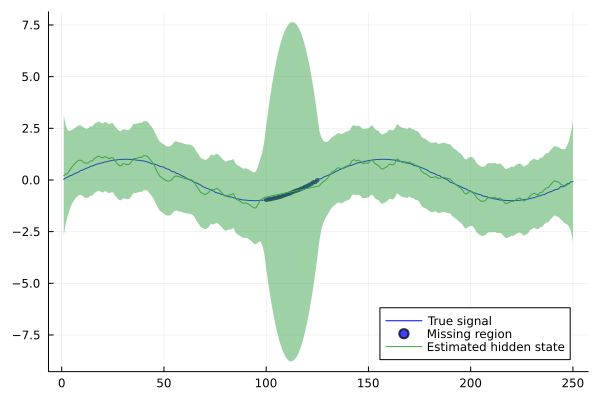

In [132]:
# plot(_real_signal, label="Noisy signal", legend=:bottomright)
# plot(_p̃ₜ, label="True signal", legend=:bottomright, color=:blue)
# plot(_s̃ₜ, label="True signal", legend=:bottomright, color=:blue)
# plot(_p̃ₜ, label="True signal", legend=:bottomright, color=:blue)
plot(_r̃ₜ, label="True signal", legend=:bottomright, color=:blue)
# plot(_yₜ, label="True signal", legend=:bottomright, color=:blue)
scatter!(
    _missing_indices, 
    # _real_signal[_missing_indices], ms=2, opacity=0.75, label="Missing region")
    # _p̃ₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    # _s̃ₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    _r̃ₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    # _yₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
plot!(
    # mean.(_result.posteriors[:x]),
    mean.(_result.posteriors[:s]), 
    # ribbon=var.(_result.posteriors[:x]), label="Estimated hidden state")
    ribbon=var.(_result.posteriors[:s]), label="Estimated hidden state")